In [79]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [80]:
df = pd.read_csv('store_customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0
...,...,...,...,...,...
995,1995,M,80.0,133.3,1.0
996,1996,M,44.0,82.6,40.0
997,1997,F,46.0,67.7,26.0
998,1998,F,28.0,45.7,59.0


In [81]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [82]:
df.shape

(1000, 5)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [84]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [85]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Spending Score (1-100)'] = df['Spending Score (1-100)'].fillna(df['Spending Score (1-100)'].mean())
df['Annual Income (k$)'] = df['Annual Income (k$)'].fillna(df['Annual Income (k$)'].mean())
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [86]:
df.isnull().sum()


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [87]:
df.duplicated().sum()

np.int64(0)

In [88]:
df.columns


Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [89]:
df.columns = [
    'CustomerID',
    'Gender',
    'Age',
    'Annual Income',
    'Spending Score'
]

In [90]:
df.head()

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [91]:
df.describe()

,CustomerID,Age,Annual Income,Spending Score
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.359579,28.571134,20.041133
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,35.075000,31.750000
50%,1499.500000,36.000000,49.150000,46.000000
75%,1749.250000,44.000000,79.325000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


<function matplotlib.pyplot.show(close=None, block=None)>

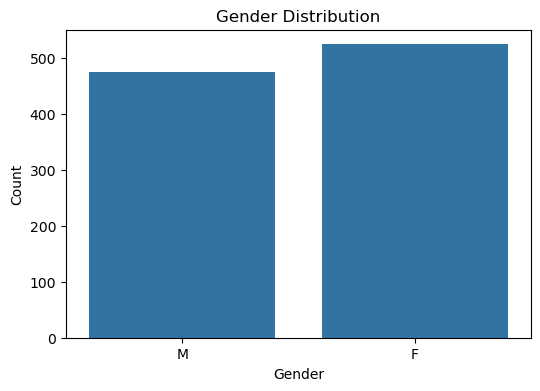

In [92]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Gender')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show

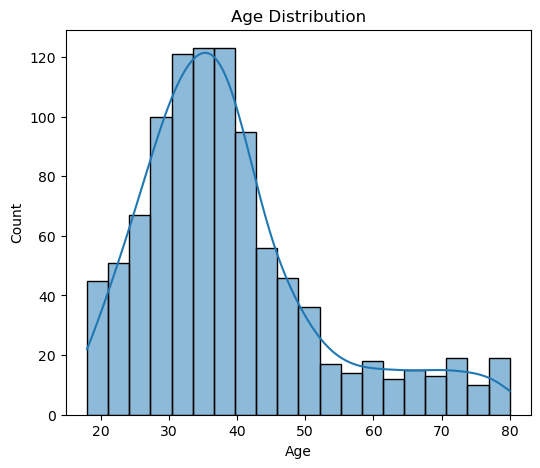

In [145]:
plt.figure(figsize=(6,5))
sns.histplot(df['Age'],bins = 20,kde = True)
plt.title('Age Distribution')
plt.show()


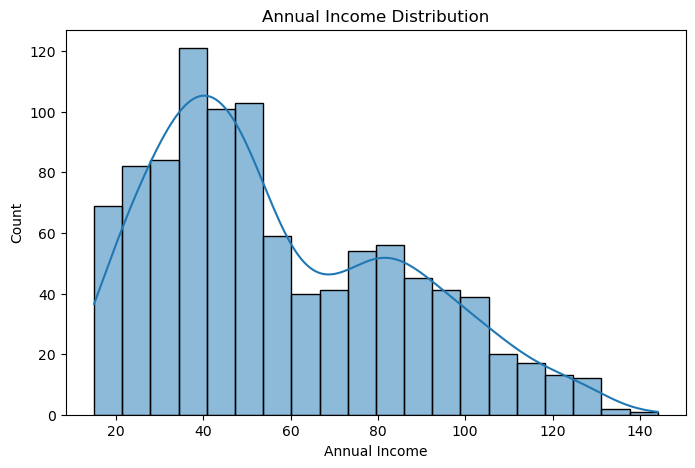

In [94]:
plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income'],bins=20,kde=True)
plt.title('Annual Income Distribution')
plt.show()

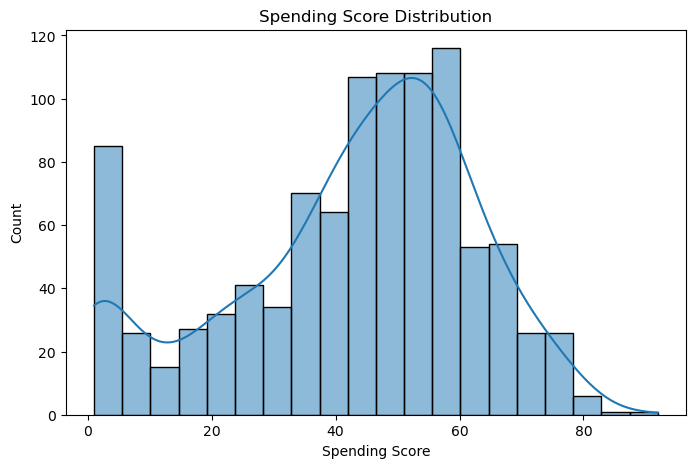

In [95]:
plt.figure(figsize=(8,5))
sns.histplot(df['Spending Score'],bins=20,kde=True)
plt.title('Spending Score Distribution')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

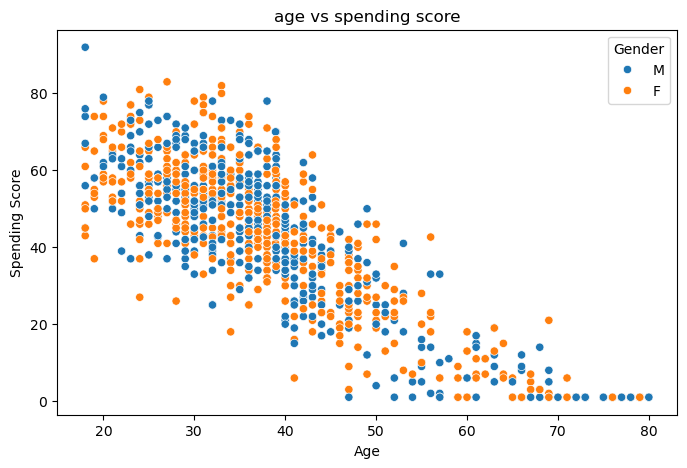

In [96]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x='Age',
                y='Spending Score',hue = 'Gender')
plt.title('age vs spending score')
plt.show

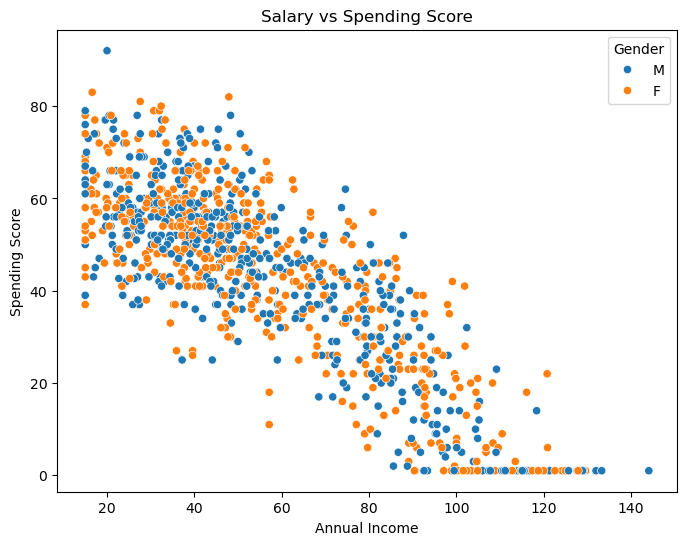

In [97]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,
                x='Annual Income',
                y='Spending Score',
                hue='Gender')
plt.title('Salary vs Spending Score')
plt.show()

In [98]:
df['Gender'] = df['Gender'].map({'M':1,'F':0})

In [99]:
df.head(100)

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1000,1,39.0,59.9,58.0
1,1001,1,34.0,48.4,37.0
2,1002,0,40.0,70.5,26.0
3,1003,0,47.0,81.1,30.0
4,1004,0,33.0,42.1,58.0
...,...,...,...,...,...
95,1095,0,23.0,21.3,72.0
96,1096,1,37.0,53.7,52.0
97,1097,0,37.0,41.0,66.0
98,1098,1,35.0,45.4,57.0


In [100]:
df['Gender'].unique()

array([1, 0])

In [123]:
x = df[['Annual Income', 'Spending Score']]

In [124]:
x

,Annual Income,Spending Score
0,59.9,58.0
1,48.4,37.0
2,70.5,26.0
3,81.1,30.0
4,42.1,58.0
...,...,...
995,133.3,1.0
996,82.6,40.0
997,67.7,26.0
998,45.7,59.0


In [125]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
x_scaled = Scaler.fit_transform(x)

In [138]:
x_scaled

array([[ 0.0963308 ,  0.76651394],
       [-0.30637475, -0.28185534],
       [ 0.46752026, -0.83100116],
       ...,
       [ 0.36947021, -0.83100116],
       [-0.40092301,  0.81643629],
       [ 1.77368695, -2.07905984]], shape=(1000, 2))

C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

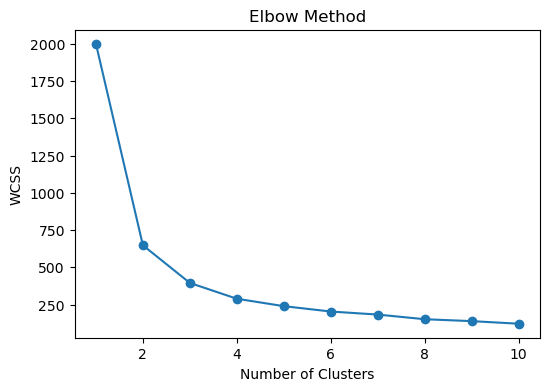

In [139]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    Kmeans = KMeans(n_clusters=i, random_state=42)
    Kmeans.fit(x_scaled)
    wcss.append(Kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [140]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 2,random_state=42)
df['clusters'] = kmeans.fit_predict(x_scaled)
df.head()


C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,CustomerID,Gender,Age,Annual Income,Spending Score,clusters
0,1000,1,39.0,59.9,58.0,1
1,1001,1,34.0,48.4,37.0,1
2,1002,0,40.0,70.5,26.0,0
3,1003,0,47.0,81.1,30.0,0
4,1004,0,33.0,42.1,58.0,1


In [141]:
df['clusters'].value_counts()

clusters
1    668
0    332
Name: count, dtype: int64

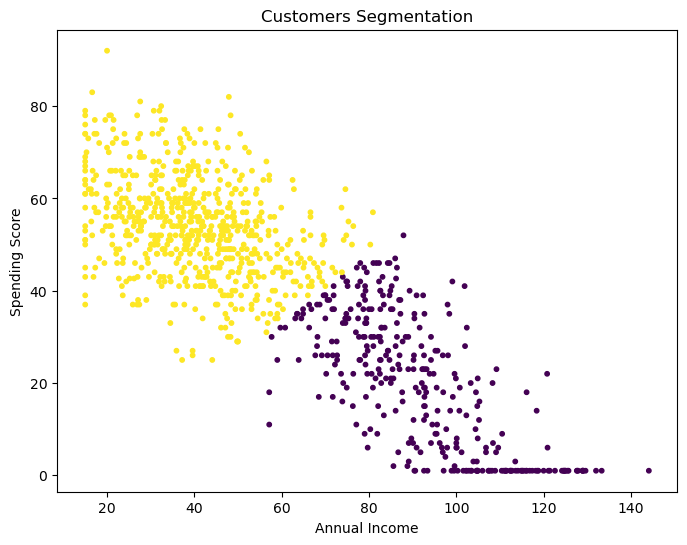

In [146]:
plt.figure(figsize=(8,6))

plt.scatter(df['Annual Income'],
            df['Spending Score'],
            c=df['clusters'],
            cmap='viridis',
            s = 10)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customers Segmentation')
plt.show()

In [143]:
df.groupby('clusters').mean(numeric_only=True)

,CustomerID,Gender,Age,Annual Income,Spending Score
clusters,,,,,
0,1617.798193,0.472892,53.367276,91.610537,20.125439
1,1440.705090,0.476048,31.762991,40.021554,53.838667


In [144]:
df['clusters'].value_counts()

clusters
1    668
0    332
Name: count, dtype: int64

# Business Insights

## Cluster 0

- Average Age: **53.36 years**
- Average Annual Income: **91.61k**
- Average Spending Score: **20.13**

### Observation
Customers in this cluster have a high annual income but a low spending score. These customers have strong purchasing power but spend less, making them an important target group for the business.

### Recommendation
- Offer personalized discounts.
- Introduce premium membership programs.
- Recommend high-value products.
- Use targeted email and marketing.

---

## Cluster 1

- Average Age: **31.76 years**
- Average Annual Income: **40.02k**
- Average Spending Score: **53.84**

### Observation
Customers in this cluster are younger and have moderate income, but they spend more frequently. They represent the most active customer segment.

### Recommendation
- Provide cashback offers.
- Give them discounts.
- Recommend affordable product bundles.

---

# Overall Findings

- The dataset was successfully divided into **2 customer segments** using the **K-Means Clustering algorithm**.
- Customer behavior varies significantly based on age, annual income, and spending habits.
- These customer segments can help businesses design personalized marketing strategies and improve customer engagement.

---

# Conclusion

This project demonstrates how **Machine Learning (K-Means Clustering)** can be used to segment customers based on their behavior. Customer segmentation enables businesses to understand their customers better,improve customer satisfaction, and increase overall business revenue.